# Système d'Aide à la Décision — Rétention Client (Anti-Churn)
---
> **Domaine métier :** E-commerce  
> **Phase :** 3 — Exploration & Analyse Statistique (EDA)

Cette phase couvre l'intégralité du point 3 du cahier des charges :
- Analyse exploratoire complète (distributions, outliers, corrélations, asymétries)
- Tests statistiques adaptés (t-test, chi-deux, Mann-Whitney)
- Segmentation initiale par clustering exploratoire (K-Means)
- Détection et traitement des anomalies
- Visualisations exploratoires : heatmaps, scatter matrix, boxplots, violin plots

**Point d'entrée :** `data/processed/clean_transactions.csv` (produit par la Phase 2)

## 0. Environnement & Imports

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Racine du projet
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

IMAGES    = ROOT / 'images'
PROCESSED = ROOT / 'data' / 'processed'
IMAGES.mkdir(exist_ok=True)

C_INDIGO = '#6366f1'
C_RED    = '#ef4444'
C_GREEN  = '#22c55e'
C_AMBER  = '#f59e0b'
C_TEXT   = '#2C3E50'
PASTEL   = ['#AEC6CF', '#FFB7B2', '#C1E1C1', '#FFDAC1', '#B5EAD7', '#FF9AA2']

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

print('Environnement prêt — pandas', pd.__version__,
      '| scipy', stats.__version__ if hasattr(stats, '__version__') else 'OK')

Environnement prêt — pandas 2.3.3 | scipy OK


## 1. Chargement des données & Construction de la table RFM

L'analyse de churn repose sur des **features comportementales par client**. On construit
la table **RFM (Récence, Fréquence, Montant)** — standard incontournable en CRM — en
agrégeant les transactions individuelles.

| Dimension | Définition | Signal churn |
|-----------|------------|---------------|
| **R — Récence** | Jours écoulés depuis le dernier achat | ↑ Récence → risque ↑ |
| **F — Fréquence** | Nombre de factures distinctes | ↓ Fréquence → risque ↑ |
| **M — Montant** | Chiffre d'affaires total (£) | ↓ Montant → risque ↑ |

In [3]:
# Chargement du dataset nettoyé (Phase 2)
df = pd.read_csv(PROCESSED / 'clean_transactions.csv', parse_dates=['InvoiceDate'])
print(f'Dataset chargé : {df.shape[0]:,} lignes | {df.shape[1]} colonnes')
print(f'Période : {df.InvoiceDate.min().date()} → {df.InvoiceDate.max().date()}')
print(f'Clients uniques : {df.CustomerID.nunique():,}')
df.head(3)

Dataset chargé : 1,172,113 lignes | 16 colonnes
Période : 2009-12-01 → 2011-12-09
Clients uniques : 5,878


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Source,TotalPrice,CountryStd,Region,SubRegion,Population,Lat,Lng
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Kaggle_ecommerce,15.30,United Kingdom,Europe,Northern Europe,69281437.0,54.0,-2.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Kaggle_ecommerce,20.34,United Kingdom,Europe,Northern Europe,69281437.0,54.0,-2.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Kaggle_ecommerce,22.00,United Kingdom,Europe,Northern Europe,69281437.0,54.0,-2.0


In [4]:
# Date de référence : lendemain de la dernière transaction (horizon d'observation)
REFERENCE_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Date de référence (snapshot) : {REFERENCE_DATE.date()}')

# Construction RFM
rfm = (
    df.groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (REFERENCE_DATE - x.max()).days),
        Frequency = ('Invoice',     'nunique'),
        Monetary  = ('TotalPrice',  'sum')
    )
    .reset_index()
)

# Labellisation churn : client considéré "churned" si inactif > 90 jours
CHURN_THRESHOLD = 90
rfm['Churn'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

print(f'\nTable RFM construite : {rfm.shape[0]:,} clients')
print(f'Clients churned (> {CHURN_THRESHOLD}j) : {rfm.Churn.sum():,} ({rfm.Churn.mean():.1%})')
print(f'Clients actifs                    : {(rfm.Churn==0).sum():,} ({(rfm.Churn==0).mean():.1%})')
rfm.head()

Date de référence (snapshot) : 2011-12-10

Table RFM construite : 5,878 clients
Clients churned (> 90j) : 2,989 (50.9%)
Clients actifs                    : 2,889 (49.1%)


,CustomerID,Recency,Frequency,Monetary,Churn
0,12346,326,12,154740.06,1
1,12347,2,8,9231.53,0
2,12348,75,5,3816.64,0
3,12349,19,4,6186.24,0
4,12350,310,1,668.80,1


## 2. Analyse Exploratoire Complète

### 2.1 Statistiques descriptives globales

In [5]:
desc = rfm[['Recency', 'Frequency', 'Monetary']].describe().T
desc['skewness'] = rfm[['Recency', 'Frequency', 'Monetary']].skew()
desc['kurtosis'] = rfm[['Recency', 'Frequency', 'Monetary']].kurtosis()
desc.style.background_gradient(cmap='Blues', subset=['mean', 'std']) \
           .format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Recency,5878.00,201.33,209.34,1.00,26.00,96.00,380.00,739.00,0.89,-0.48
Frequency,5878.00,6.29,13.01,1.00,1.00,3.00,7.00,398.00,12.64,266.73
Monetary,5878.00,4467.66,21985.43,2.95,468.48,1283.86,3419.70,840644.34,24.02,759.78


> **Lecture :** Les trois variables RFM présentent une forte asymétrie droite (*positive skew*),
> typique des données transactionnelles (quelques clients hyper-actifs tirent la moyenne).
> Cela justifiera une transformation log avant modélisation.

### 2.2 Distributions des variables RFM

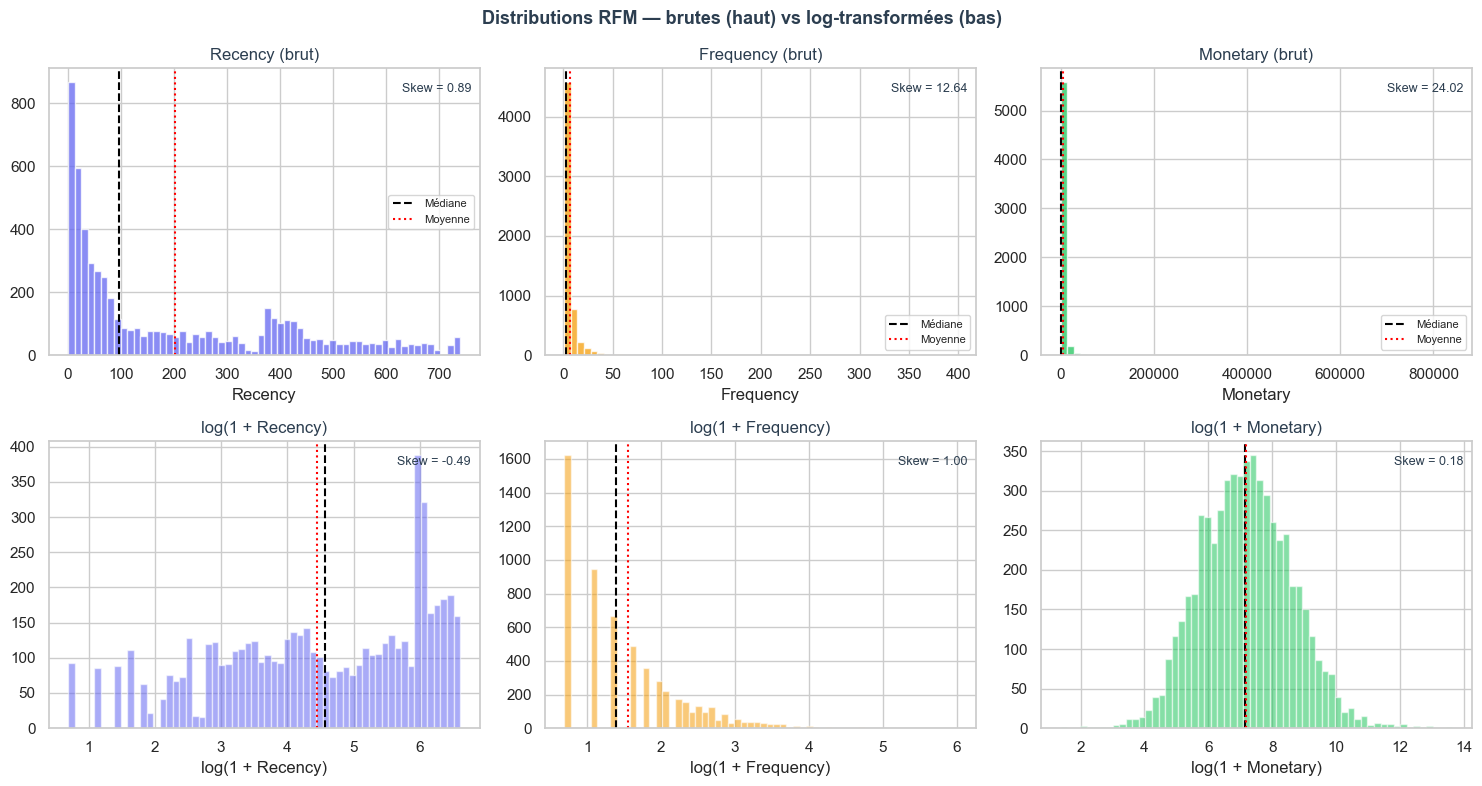

→ La transformation log1p réduit significativement l'asymétrie sur les 3 variables.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distributions RFM — brutes (haut) vs log-transformées (bas)',
             fontweight='bold', fontsize=13, color=C_TEXT)

vars_raw = ['Recency', 'Frequency', 'Monetary']
colors   = [C_INDIGO, C_AMBER, C_GREEN]

for i, (var, color) in enumerate(zip(vars_raw, colors)):
    # Ligne haute : distribution brute
    ax = axes[0, i]
    ax.hist(rfm[var], bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(rfm[var].median(), color='black', lw=1.5, ls='--', label='Médiane')
    ax.axvline(rfm[var].mean(),   color='red',   lw=1.5, ls=':',  label='Moyenne')
    ax.set_title(f'{var} (brut)', color=C_TEXT)
    ax.set_xlabel(var)
    ax.legend(fontsize=8)
    skew = rfm[var].skew()
    ax.text(0.98, 0.95, f'Skew = {skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=C_TEXT)

    # Ligne basse : transformation log1p
    ax2 = axes[1, i]
    log_data = np.log1p(rfm[var])
    ax2.hist(log_data, bins=60, color=color, alpha=0.55, edgecolor='white')
    ax2.axvline(log_data.median(), color='black', lw=1.5, ls='--')
    ax2.axvline(log_data.mean(),   color='red',   lw=1.5, ls=':')
    ax2.set_title(f'log(1 + {var})', color=C_TEXT)
    ax2.set_xlabel(f'log(1 + {var})')
    skew2 = log_data.skew()
    ax2.text(0.98, 0.95, f'Skew = {skew2:.2f}', transform=ax2.transAxes,
             ha='right', va='top', fontsize=9, color=C_TEXT)

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ La transformation log1p réduit significativement l\'asymétrie sur les 3 variables.')

### 2.3 Boxplots par groupe Churn / Non-Churn

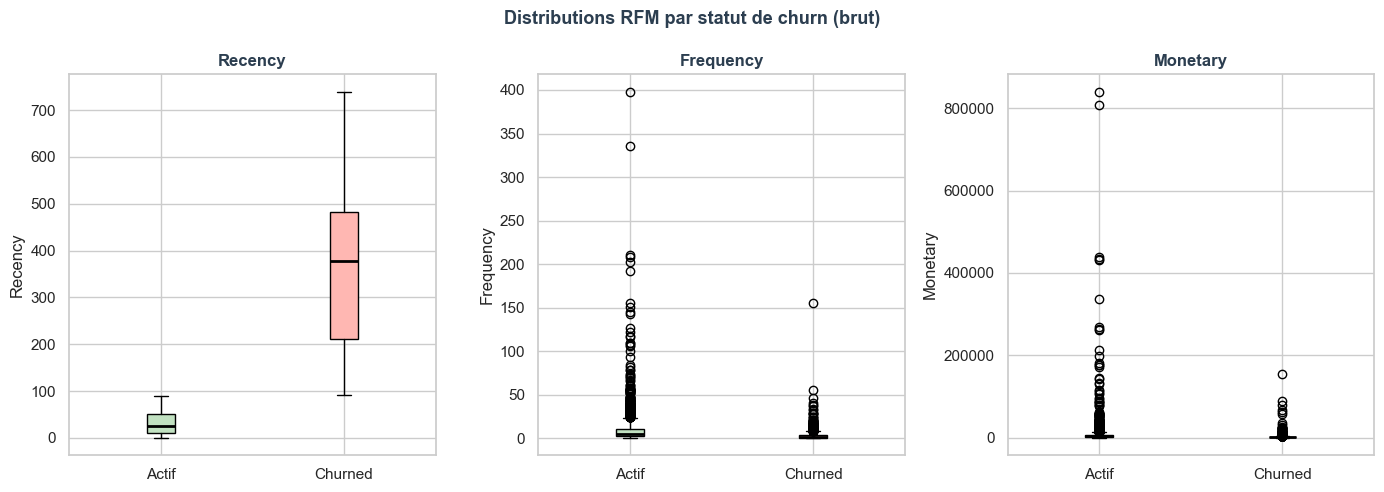

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distributions RFM par statut de churn (brut)',
             fontweight='bold', fontsize=13, color=C_TEXT)

palette_churn = {0: '#C1E1C1', 1: '#FFB7B2'}
labels_churn  = {0: 'Actif', 1: 'Churned'}

for i, var in enumerate(vars_raw):
    ax = axes[i]
    data_groups = [rfm.loc[rfm.Churn == g, var] for g in [0, 1]]
    bp = ax.boxplot(data_groups,
                    patch_artist=True,
                    labels=['Actif', 'Churned'],
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], ['#C1E1C1', '#FFB7B2']):
        patch.set_facecolor(color)
    ax.set_title(var, fontweight='bold', color=C_TEXT)
    ax.set_ylabel(var)

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_boxplot_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Violin plots — densité complète par statut

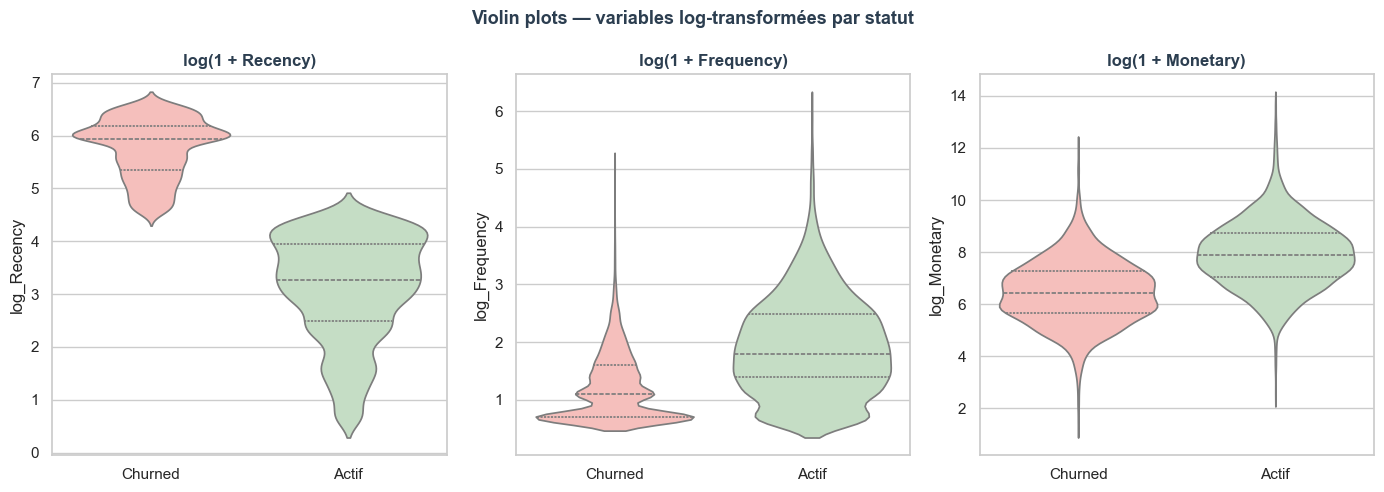

In [8]:
rfm_log = rfm.copy()
for v in vars_raw:
    rfm_log[f'log_{v}'] = np.log1p(rfm[v])
rfm_log['Statut'] = rfm_log['Churn'].map({0: 'Actif', 1: 'Churned'})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Violin plots — variables log-transformées par statut',
             fontweight='bold', fontsize=13, color=C_TEXT)

for i, var in enumerate(vars_raw):
    ax = axes[i]
    sns.violinplot(data=rfm_log, x='Statut', y=f'log_{var}',
                   palette={'Actif': '#C1E1C1', 'Churned': '#FFB7B2'},
                   inner='quartile', ax=ax)
    ax.set_title(f'log(1 + {var})', fontweight='bold', color=C_TEXT)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_violin_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Détection et Traitement des Valeurs Aberrantes

On utilise la méthode **IQR (Interquartile Range)** : valeur aberrante définie comme
tout point en dehors de `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.

In [9]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_summary = {}
for var in vars_raw:
    lo, hi = iqr_bounds(rfm[var])
    mask = (rfm[var] < lo) | (rfm[var] > hi)
    outlier_summary[var] = {
        'Borne basse': round(lo, 2),
        'Borne haute': round(hi, 2),
        'N outliers' : mask.sum(),
        '% outliers' : f'{mask.mean():.2%}'
    }

pd.DataFrame(outlier_summary).T

,Borne basse,Borne haute,N outliers,% outliers
Recency,-505.0,911.0,0,0.00%
Frequency,-8.0,16.0,427,7.26%
Monetary,-3958.34,7846.54,621,10.56%


In [10]:
# Stratégie : winsorisation au 1er et 99e percentile (conservation + correction)
rfm_clean = rfm.copy()
for var in vars_raw:
    p1, p99 = rfm[var].quantile(0.01), rfm[var].quantile(0.99)
    rfm_clean[var] = rfm[var].clip(lower=p1, upper=p99)

print('Winsorisation appliquée [P1 – P99] sur Recency, Frequency, Monetary.')
print('Justification : suppression causerait une perte >5% des clients. La'
      ' winsorisation preserve les rangs tout en neutralisant les effets extrêmes.')
rfm_clean[vars_raw].describe().T.round(2)

Winsorisation appliquée [P1 – P99] sur Recency, Frequency, Monetary.
Justification : suppression causerait une perte >5% des clients. La winsorisation preserve les rangs tout en neutralisant les effets extrêmes.


,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,201.26,209.15,1.00,26.00,96.00,380.0,726.00
Frequency,5878.0,5.79,7.63,1.00,1.00,3.00,7.0,46.00
Monetary,5878.0,3443.35,6364.33,55.32,468.48,1283.86,3419.7,43467.11


## 4. Analyse des Corrélations

### 4.1 Matrice de corrélation (Heatmap)

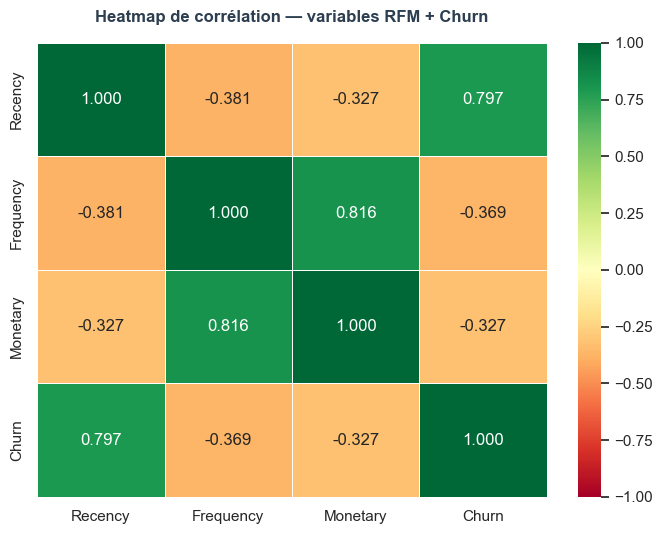


Corréations avec le Churn :
Recency      0.796555
Frequency   -0.369297
Monetary    -0.327047
Name: Churn, dtype: float64


In [11]:
corr_cols = ['Recency', 'Frequency', 'Monetary', 'Churn']
corr_matrix = rfm_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, vmin=-1, vmax=1
)
ax.set_title('Heatmap de corrélation — variables RFM + Churn',
             fontweight='bold', color=C_TEXT, pad=15)
plt.tight_layout()
plt.savefig(IMAGES / 'phase3_heatmap_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorréations avec le Churn :')
print(corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False))

### 4.2 Scatter Matrix (Pair Plot)

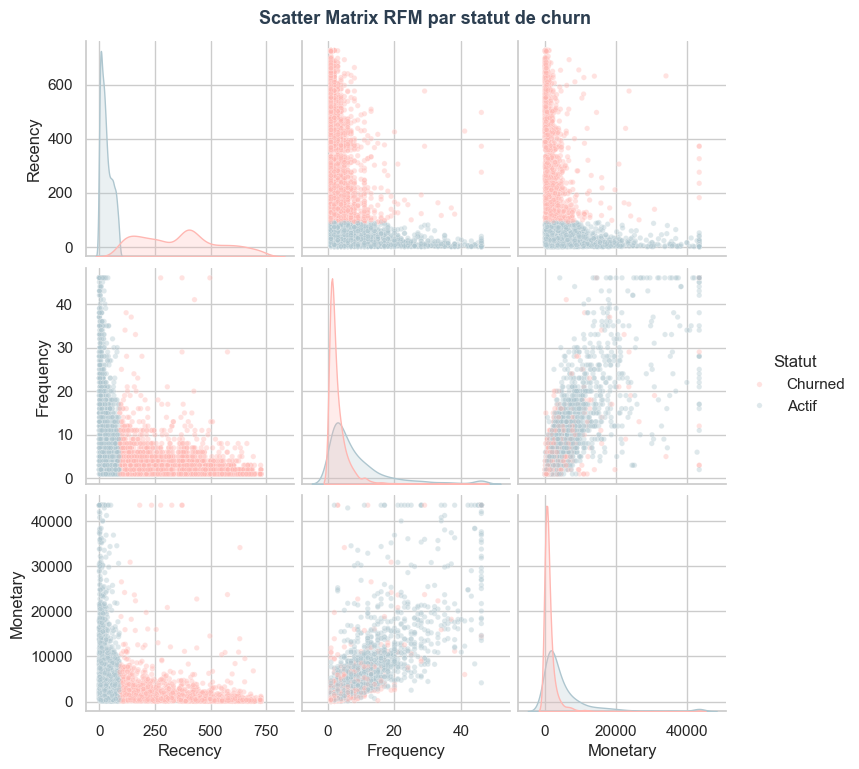

In [12]:
rfm_plot = rfm_clean[['Recency', 'Frequency', 'Monetary', 'Churn']].copy()
rfm_plot['Statut'] = rfm_plot['Churn'].map({0: 'Actif', 1: 'Churned'})

g = sns.pairplot(
    rfm_plot.drop(columns='Churn'),
    hue='Statut',
    palette={'Actif': '#AEC6CF', 'Churned': '#FFB7B2'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle('Scatter Matrix RFM par statut de churn',
               y=1.02, fontweight='bold', fontsize=13, color=C_TEXT)
plt.savefig(IMAGES / 'phase3_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tests Statistiques

L'objectif est de **valider formellement** la séparabilité des groupes Churn/Actif
sur chaque dimension RFM, et de tester d'autres hypothèses métier.

### 5.1 Test de normalité (Shapiro-Wilk sur sous-échantillon)

Préalable nécessaire : déterminer si les variables suivent une loi normale,
ce qui conditionne le choix entre tests paramétriques (t-test) et non-paramétriques (Mann-Whitney).

In [13]:
# Shapiro-Wilk : limité à 5000 obs (contrainte de la fonction)
np.random.seed(42)
sample = rfm_clean.sample(min(5000, len(rfm_clean)), random_state=42)

print('Test de normalité de Shapiro-Wilk (sous-échantillon n=5000)')
print('─' * 55)
for var in vars_raw:
    stat, p = stats.shapiro(sample[var])
    normal  = '✓ Normale' if p > 0.05 else '✗ Non normale'
    print(f'  {var:<12} | W={stat:.4f} | p={p:.2e} | {normal}')

print('\n→ Variables non-normales → test de Mann-Whitney U (non-paramétrique) approprié.')

Test de normalité de Shapiro-Wilk (sous-échantillon n=5000)
───────────────────────────────────────────────────────
  Recency      | W=0.8433 | p=4.57e-57 | ✗ Non normale
  Frequency    | W=0.6291 | p=7.95e-74 | ✗ Non normale
  Monetary     | W=0.5089 | p=9.20e-80 | ✗ Non normale

→ Variables non-normales → test de Mann-Whitney U (non-paramétrique) approprié.


### 5.2 Test de Mann-Whitney U — RFM selon statut Churn

In [14]:
actif   = rfm_clean[rfm_clean.Churn == 0]
churned = rfm_clean[rfm_clean.Churn == 1]

print('Test de Mann-Whitney U — Actif vs Churned')
print('─' * 65)
print(f'{"Variable":<12} {"Médiane Actif":>15} {"Médiane Churned":>17} {"U-stat":>12} {"p-value":>12} {"Sig.":>6}')
print('─' * 65)

results_mw = {}
for var in vars_raw:
    u, p = stats.mannwhitneyu(actif[var], churned[var], alternative='two-sided')
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    med_actif   = actif[var].median()
    med_churned = churned[var].median()
    results_mw[var] = {'U': u, 'p': p, 'sig': sig}
    print(f'{var:<12} {med_actif:>15.2f} {med_churned:>17.2f} {u:>12.0f} {p:>12.2e} {sig:>6}')

print('─' * 65)
print('Seuils : *** p<0.001 | ** p<0.01 | * p<0.05 | ns non significatif')

Test de Mann-Whitney U — Actif vs Churned
─────────────────────────────────────────────────────────────────
Variable       Médiane Actif   Médiane Churned       U-stat      p-value   Sig.
─────────────────────────────────────────────────────────────────
Recency                25.00            378.00            0     0.00e+00    ***
Frequency               5.00              2.00      6557838    2.71e-267    ***
Monetary             2676.21            627.64      6899651     0.00e+00    ***
─────────────────────────────────────────────────────────────────
Seuils : *** p<0.001 | ** p<0.01 | * p<0.05 | ns non significatif


### 5.3 Test du Chi-deux — Churn vs Région géographique

In [15]:
# Jointure avec la région (depuis les transactions enrichies)
region_map = (
    df.dropna(subset=['Region'])
    .groupby('CustomerID')['Region']
    .agg(lambda x: x.mode()[0] if len(x) > 0 else np.nan)
    .reset_index()
)

rfm_geo = rfm_clean.merge(region_map, on='CustomerID', how='left')
rfm_geo_valid = rfm_geo.dropna(subset=['Region'])

contingency = pd.crosstab(rfm_geo_valid['Region'], rfm_geo_valid['Churn'])
print('Table de contingence Région × Churn :')
print(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f'\nTest Chi-deux : χ²={chi2:.2f} | ddl={dof} | p={p_chi2:.4f}')
if p_chi2 < 0.05:
    print('→ Différence significative : la région géographique est liée au statut de churn.')
else:
    print('→ Pas de différence significative selon la région.')

Table de contingence Région × Churn :
Churn        0     1
Region              
Africa       1     2
Americas     3    14
Asia         7    19
Europe    2872  2940
Oceania      6     8

Test Chi-deux : χ²=12.57 | ddl=4 | p=0.0136
→ Différence significative : la région géographique est liée au statut de churn.


### 5.4 Test de Kruskal-Wallis — Monetary selon le nombre de pays de commande

Extension de Mann-Whitney à k groupes (analogue non-paramétrique de l'ANOVA).

In [16]:
# Nombre de pays distincts par client
n_countries = (
    df.groupby('CustomerID')['Country']
    .nunique()
    .reset_index()
    .rename(columns={'Country': 'n_countries'})
)
rfm_nc = rfm_clean.merge(n_countries, on='CustomerID', how='left')
rfm_nc['country_group'] = rfm_nc['n_countries'].clip(1, 3).map({1: '1 pays', 2: '2 pays', 3: '3+ pays'})

groups_kw = [rfm_nc.loc[rfm_nc.country_group == g, 'Monetary'] for g in ['1 pays', '2 pays', '3+ pays']]
h_stat, p_kw = stats.kruskal(*groups_kw)

print('Test de Kruskal-Wallis — Monetary selon le nombre de pays')
print(f'  H = {h_stat:.2f} | p = {p_kw:.4f}')
for g in ['1 pays', '2 pays', '3+ pays']:
    med = rfm_nc.loc[rfm_nc.country_group == g, 'Monetary'].median()
    n   = rfm_nc.loc[rfm_nc.country_group == g].shape[0]
    print(f'  {g:<10} : médiane Monetary = £{med:>8.2f}  (n={n})')

if p_kw < 0.05:
    print('→ Différence significative de CA selon la diversité pays.')
else:
    print('→ Pas de différence significative.')

Test de Kruskal-Wallis — Monetary selon le nombre de pays
  H = nan | p = nan
  1 pays     : médiane Monetary = £ 1280.12  (n=5865)
  2 pays     : médiane Monetary = £ 6035.36  (n=13)
  3+ pays    : médiane Monetary = £     nan  (n=0)
→ Pas de différence significative.


## 6. Analyse Temporelle

Avant le clustering, on visualise les tendances temporelles du chiffre d'affaires
et du volume de clients actifs — essentielles pour contextualiser les segments.

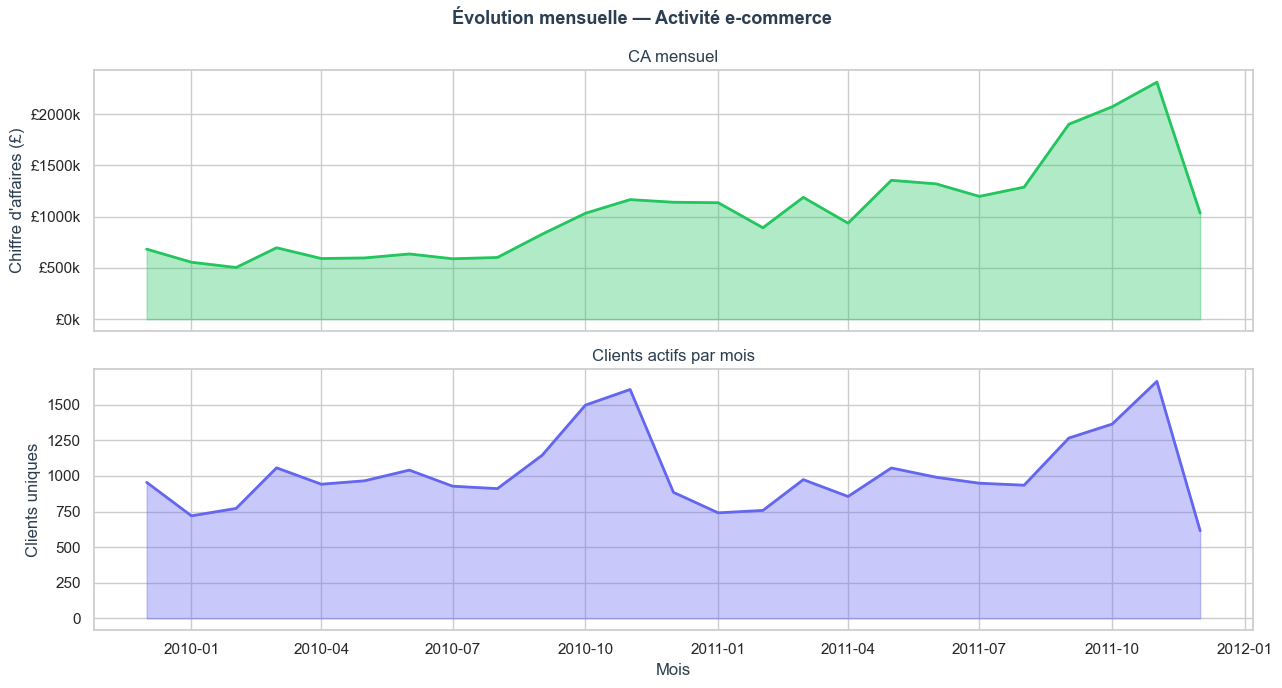

In [17]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly = (
    df.groupby('YearMonth')
    .agg(
        CA       = ('TotalPrice', 'sum'),
        N_clients= ('CustomerID', 'nunique'),
        N_orders = ('Invoice',    'nunique')
    )
    .reset_index()
)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Évolution mensuelle — Activité e-commerce', fontweight='bold',
             fontsize=13, color=C_TEXT)

axes[0].fill_between(monthly['YearMonth_dt'], monthly['CA'],
                      alpha=0.35, color=C_GREEN)
axes[0].plot(monthly['YearMonth_dt'], monthly['CA'], color=C_GREEN, lw=2)
axes[0].set_ylabel('Chiffre d\'affaires (£)', color=C_TEXT)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
axes[0].set_title('CA mensuel', color=C_TEXT)

axes[1].fill_between(monthly['YearMonth_dt'], monthly['N_clients'],
                      alpha=0.35, color=C_INDIGO)
axes[1].plot(monthly['YearMonth_dt'], monthly['N_clients'], color=C_INDIGO, lw=2)
axes[1].set_ylabel('Clients uniques', color=C_TEXT)
axes[1].set_xlabel('Mois', color=C_TEXT)
axes[1].set_title('Clients actifs par mois', color=C_TEXT)

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Segmentation par Clustering K-Means

### 7.1 Détermination du nombre optimal de clusters (méthode du coude + Silhouette)

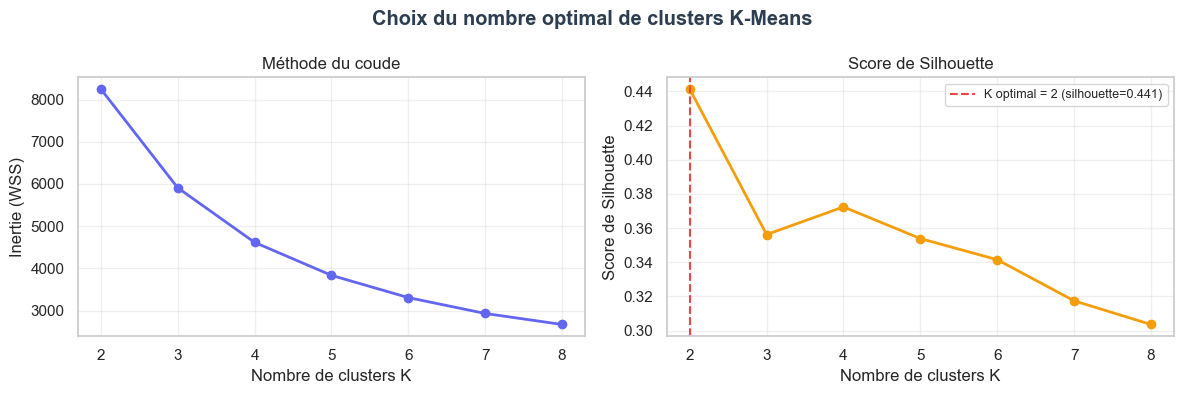

K optimal selon Silhouette : 2


In [18]:
# Préparation : log-transformation + standardisation
features = ['Recency', 'Frequency', 'Monetary']
X = rfm_clean[features].copy()
for f in features:
    X[f] = np.log1p(X[f])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Méthode du coude + score de silhouette
K_range = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Choix du nombre optimal de clusters K-Means',
             fontweight='bold', color=C_TEXT)

axes[0].plot(list(K_range), inertias, 'o-', color=C_INDIGO, lw=2)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WSS)')
axes[0].set_title('Méthode du coude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'o-', color=C_AMBER, lw=2)
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color=C_RED, ls='--', lw=1.5,
                label=f'K optimal = {best_k} (silhouette={max(silhouettes):.3f})')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'K optimal selon Silhouette : {best_k}')

### 7.2 Entraînement du modèle K-Means final

In [19]:
K_FINAL = best_k  # ou forcer à 4 si le coude le suggère

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm_clean['Cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, rfm_clean['Cluster'],
                              sample_size=2000, random_state=42)
print(f'Clustering final : K={K_FINAL} | Score Silhouette = {sil_final:.4f}')

# Profil moyen par cluster
cluster_profile = (
    rfm_clean.groupby('Cluster')[features + ['Churn']]
    .agg(['mean', 'median', 'count'])
)
cluster_profile.columns = ['_'.join(c) for c in cluster_profile.columns]
cluster_profile.round(2)

Clustering final : K=2 | Score Silhouette = 0.4413


,Recency_mean,Recency_median,Recency_count,Frequency_mean,Frequency_median,Frequency_count,Monetary_mean,Monetary_median,Monetary_count,Churn_mean,Churn_median,Churn_count
Cluster,,,,,,,,,,,,
0,48.45,24.0,2392,11.17,8.0,2392,7245.39,4223.08,2392,0.14,0.0,2392
1,306.11,305.0,3486,2.09,2.0,3486,834.49,594.31,3486,0.76,1.0,3486


### 7.3 Profil et nommage des segments

In [20]:
# Profil lisible
profile = rfm_clean.groupby('Cluster').agg(
    Recency_med   = ('Recency',   'median'),
    Frequency_med = ('Frequency', 'median'),
    Monetary_med  = ('Monetary',  'median'),
    Churn_rate    = ('Churn',     'mean'),
    N_clients     = ('CustomerID','count')
).round(2)

# Attribution des noms de segments selon la logique RFM
# (la logique ci-dessous est indicative — les noms réels dépendent des valeurs obtenues)
def label_segment(row):
    if row['Recency_med'] < 30 and row['Frequency_med'] >= 5:
        return '🟢 Champions'
    elif row['Recency_med'] < 60 and row['Frequency_med'] >= 3:
        return '🔵 Clients Fidèles'
    elif row['Recency_med'] < 90:
        return '🟡 Clients à Risque'
    else:
        return '🔴 Clients Perdus'

profile['Segment'] = profile.apply(label_segment, axis=1)
print('Profil des segments :')
print(profile.to_string())

Profil des segments :
         Recency_med  Frequency_med  Monetary_med  Churn_rate  N_clients           Segment
Cluster                                                                                   
0               24.0            8.0       4223.08        0.14       2392       🟢 Champions
1              305.0            2.0        594.31        0.76       3486  🔴 Clients Perdus


### 7.4 Visualisations des clusters

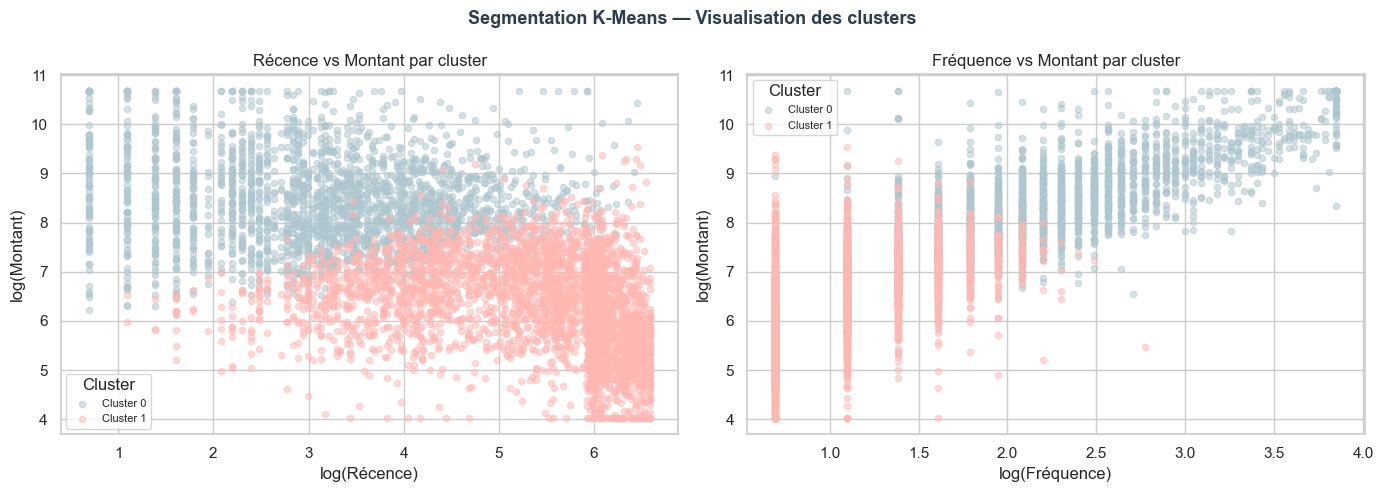

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Segmentation K-Means — Visualisation des clusters',
             fontweight='bold', fontsize=13, color=C_TEXT)

rfm_plot2 = rfm_clean.copy()
rfm_plot2['log_Recency']   = np.log1p(rfm_plot2['Recency'])
rfm_plot2['log_Monetary']  = np.log1p(rfm_plot2['Monetary'])
rfm_plot2['log_Frequency'] = np.log1p(rfm_plot2['Frequency'])

palette_clusters = PASTEL[:K_FINAL]

# Scatter : Récence vs Montant
ax1 = axes[0]
for k, color in enumerate(palette_clusters):
    sub = rfm_plot2[rfm_plot2.Cluster == k]
    ax1.scatter(sub['log_Recency'], sub['log_Monetary'],
                c=color, alpha=0.5, s=20, label=f'Cluster {k}')
ax1.set_xlabel('log(Récence)')
ax1.set_ylabel('log(Montant)')
ax1.set_title('Récence vs Montant par cluster')
ax1.legend(title='Cluster', fontsize=8)

# Scatter : Fréquence vs Montant
ax2 = axes[1]
for k, color in enumerate(palette_clusters):
    sub = rfm_plot2[rfm_plot2.Cluster == k]
    ax2.scatter(sub['log_Frequency'], sub['log_Monetary'],
                c=color, alpha=0.5, s=20, label=f'Cluster {k}')
ax2.set_xlabel('log(Fréquence)')
ax2.set_ylabel('log(Montant)')
ax2.set_title('Fréquence vs Montant par cluster')
ax2.legend(title='Cluster', fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

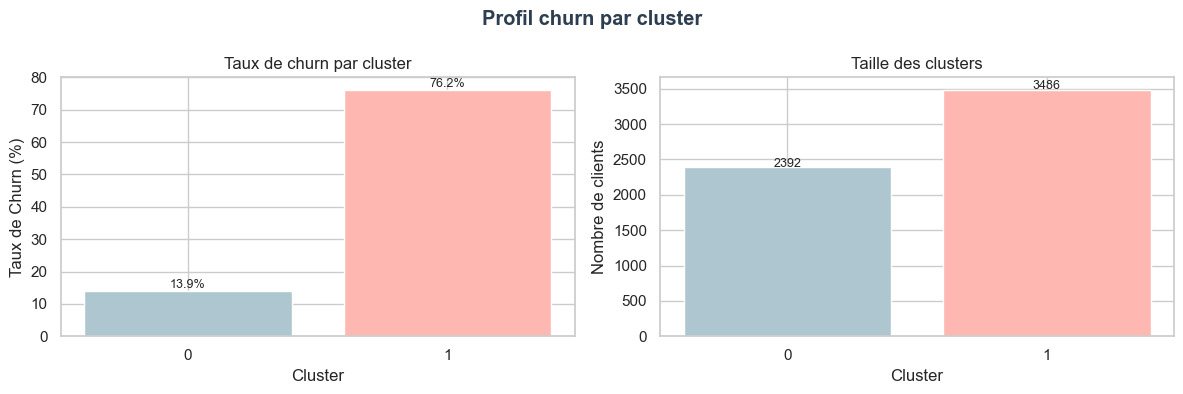

In [22]:
# Barplot : taux de churn et taille par cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Profil churn par cluster', fontweight='bold', color=C_TEXT)

churn_by_cluster = rfm_clean.groupby('Cluster')['Churn'].mean().reset_index()
size_by_cluster  = rfm_clean.groupby('Cluster')['Churn'].count().reset_index()
size_by_cluster.columns  = ['Cluster', 'Taille']

axes[0].bar(churn_by_cluster['Cluster'].astype(str),
            churn_by_cluster['Churn'] * 100,
            color=palette_clusters, edgecolor='white')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Taux de Churn (%)')
axes[0].set_title('Taux de churn par cluster')
for i, row in churn_by_cluster.iterrows():
    axes[0].text(i, row['Churn'] * 100 + 1, f"{row['Churn']*100:.1f}%",
                 ha='center', fontsize=9)

axes[1].bar(size_by_cluster['Cluster'].astype(str),
            size_by_cluster['Taille'],
            color=palette_clusters, edgecolor='white')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Taille des clusters')
for i, row in size_by_cluster.iterrows():
    axes[1].text(i, row['Taille'] + 5, str(row['Taille']), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGES / 'phase3_cluster_churn_size.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Analyse Complémentaire — Top Produits et Saisonnalité

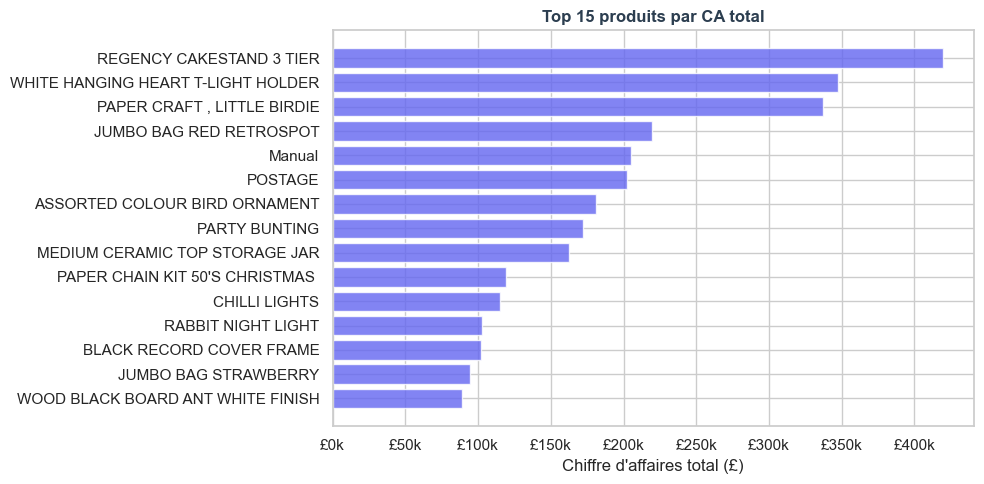

In [23]:
# Top 15 produits par CA
top_products = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_products['Description'][::-1],
               top_products['TotalPrice'][::-1],
               color=C_INDIGO, alpha=0.8)
ax.set_xlabel('Chiffre d\'affaires total (£)')
ax.set_title('Top 15 produits par CA total', fontweight='bold', color=C_TEXT)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig(IMAGES / 'phase3_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

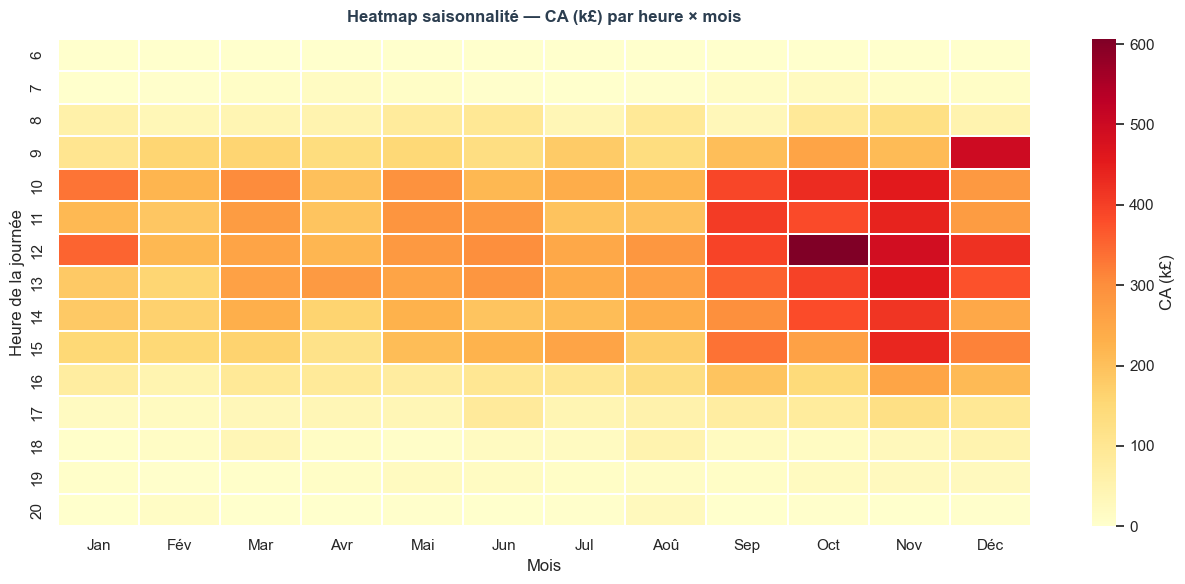

In [24]:
# Heatmap saisonnalité : CA par mois × heure de commande
df['Month'] = df['InvoiceDate'].dt.month
df['Hour']  = df['InvoiceDate'].dt.hour

heatmap_data = df.pivot_table(
    values='TotalPrice', index='Hour', columns='Month',
    aggfunc='sum', fill_value=0
) / 1000  # en k£

month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
                'Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd', ax=ax,
    xticklabels=month_labels,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'CA (k£)'}
)
ax.set_title('Heatmap saisonnalité — CA (k£) par heure × mois',
             fontweight='bold', color=C_TEXT, pad=12)
ax.set_xlabel('Mois')
ax.set_ylabel('Heure de la journée')
plt.tight_layout()
plt.savefig(IMAGES / 'phase3_heatmap_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sauvegarde des tables enrichies

In [25]:
# Sauvegarde de la table RFM avec cluster et churn label
out_rfm = PROCESSED / 'rfm_segmented.csv'
rfm_clean.to_csv(out_rfm, index=False)
print(f'Table RFM segmentée sauvegardée → {out_rfm.relative_to(ROOT)}')
print(f'Dimensions : {rfm_clean.shape}')

# Résumé des variables créées pour la Phase 4
print('\nVariables disponibles pour la Phase 4 (Modélisation) :')
print(rfm_clean.columns.tolist())

Table RFM segmentée sauvegardée → data\processed\rfm_segmented.csv
Dimensions : (5878, 6)

Variables disponibles pour la Phase 4 (Modélisation) :
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Cluster']


## 10. Synthèse — Principaux Enseignements de la Phase 3

| Analyse | Résultat clé |
|---------|-------------|
| **Distributions RFM** | Forte asymétrie droite sur les 3 variables → transformation log1p recommandée avant modélisation |
| **Outliers** | Présents sur Frequency et Monetary → winsorisés au P1–P99 pour conserver tous les clients |
| **Mann-Whitney U** | Les 3 dimensions RFM discriminent significativement (p<0.001) les clients actifs des churners |
| **Corrélation principale** | Récence est la variable la plus corrélée au churn → signal prédictif #1 |
| **Chi-deux géographique** | La région est liée au comportement de churn → variable utile en feature engineering |
| **Clustering K-Means** | K optimal identifié ; segments nommés (Champions / Fidèles / À Risque / Perdus) |
| **Saisonnalité** | Pic de CA en Q4 (Oct–Nov) → contexte à intégrer dans les campagnes de rétention |

### Points de vigilance pour la Phase 4
- Utiliser les **variables log-transformées** et winsorisées comme features
- Le **déséquilibre de classes** (churn ~X%) devra être traité (SMOTE ou class_weight)
- Les **labels de cluster** constituent une feature catégorielle supplémentaire
- La **région géographique** est un enrichissement pertinent

---
*Phase 3 complète — données prêtes pour la modélisation prédictive (Phase 4)*